# Convert images from RGB to HSV and colour class

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import rgb_to_hsv, hsv_to_rgb

In [2]:
dataset = np.load('../data/rec_00.npz')

images = dataset['img']
vecs = dataset['vec']

images.shape, vecs.shape

((64, 256, 5, 48, 96), (64, 256, 46))

In [3]:
vecs[0, 0]

array([ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
        0.0000000e+00,  2.3223203e-02,  2.6924878e-02,  2.2297224e-02,
        2.3542449e-02, -3.2093409e-05, -2.6821793e-04, -3.2051533e-04,
        1.0065836e-01, -5.5816025e-04, -9.8332596e-01, -8.8892162e-02,
        2.0303459e-01,  4.2888740e-01,  8.4313726e-01,  7.8431375e-02,
        5.2941179e-01,  1.0000000e+00,  5.6862748e-01,  0.0000000e+00,
        2.6422203e-01, -7.3662823e-01,  1.5298098e-01, -7.8203720e-01,
        0.0000000e+00,  0.0000000e+00, -6.6065675e-01,  7.5068820e-01,
        0.0000000e+00,  3.5043159e-01,  0.0000000e+00,  0.0000000e+00,
        0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
        4.1666669e-03, -4.1666669e-03,  0.0000000e+00,  0.0000000e+00,
        0.0000000e+00,  1.0000000e+00], dtype=float32)

### Test torchvision method

In [4]:
def _rgb_2_hsv(img, hwc_over_chw: bool = False):
    if hwc_over_chw:
        r, g, b = img[..., 0], img[..., 1], img[..., 2]

    else:
        r, g, b = img[..., 0, :, :], img[..., 1, :, :], img[..., 2, :, :]

    maxc = np.max(img, axis=-1 if hwc_over_chw else -3)
    minc = np.min(img, axis=-1 if hwc_over_chw else -3)

    eqc = maxc == minc
    cr = maxc - minc

    ones = np.ones_like(maxc)
    s = cr / np.where(eqc, ones, maxc)

    cr_divisor = np.where(eqc, ones, cr)
    rc = (maxc - r) / cr_divisor
    gc = (maxc - g) / cr_divisor
    bc = (maxc - b) / cr_divisor

    hr = (maxc == r) * (bc - gc)
    hg = ((maxc == g) & (maxc != r)) * (2.0 + rc - bc)
    hb = ((maxc != g) & (maxc != r)) * (4.0 + gc - rc)
    h = hr + hg + hb
    h = np.fmod((h / 6.0 + 1.0), 1.0)

    return np.stack((h, s, maxc), axis=-1 if hwc_over_chw else -3)

In [5]:
random_idcs = np.random.randint(256, size=32)
random_images = images[0, random_idcs, :3]

np.max(np.abs(rgb_to_hsv(np.moveaxis(random_images, 1, -1)) - np.moveaxis(_rgb_2_hsv(random_images), 1, -1)))

1.7881393e-07

## Classes

In [6]:
SEG_CLS_NULL = 0
SEG_CLS_PLANE = 1
SEG_CLS_WALL = 2
SEG_CLS_OBJ = 3
SEG_CLS_BOT = 4
SEG_CLS_BODY = 5
SEG_CLS_CARGO = 6
N_SEG_CLASSES = 7

CLR_CLS_BLACK = 0
CLR_CLS_WHITE = 1
CLR_CLS_RED = 7
CLR_CLS_BOT = 20
CLR_CLS_FLOOR = 21
CLR_CLS_SKY = 22
N_CLR_CLASSES = 23

# Object, body, cargo
rgb_cls_main = np.array([
    [0, 0, 0],
    [255, 255, 255],
    [155, 205, 0],
    [0, 145, 0],
    [255, 145, 0],
    [0, 0, 255],
    [0, 160, 200],
    [255, 0, 0],
    [100, 50, 0],
    [115, 20, 165],
    [215, 20, 135]]) / 255.

# Env. elements
rgb_cls_wall = np.array([
    [185, 255, 175],
    [255, 255, 160],
    [255, 160, 205],
    [255, 205, 135],
    [175, 195, 255],
    [225, 160, 255],
    [175, 245, 255],
    [125, 235, 205],
    [255, 215, 215]]) / 255.

# Bot, floor, sky
rgb_cls_othr = np.array([
    [102, 102, 102],
    [168, 168, 168],  # [127, 127, 127],
    [230, 245, 255]]) / 255.

rgb_classes = np.concatenate((rgb_cls_main, rgb_cls_wall, rgb_cls_othr))
hsv_classes = _rgb_2_hsv(rgb_classes, hwc_over_chw=True)

hsv_cls_main = hsv_classes[:len(rgb_cls_main)]
hsv_cls_wall = hsv_classes[len(rgb_cls_main):len(rgb_cls_main) + len(rgb_cls_wall)]
hsv_cls_othr = hsv_classes[len(rgb_cls_main) + len(rgb_cls_wall):]

In [7]:
hsv_cls_main, hsv_cls_wall, hsv_cls_othr

(array([[0.        , 0.        , 0.        ],
        [0.        , 0.        , 1.        ],
        [0.20731707, 1.        , 0.80392157],
        [0.33333333, 1.        , 0.56862745],
        [0.09477124, 1.        , 1.        ],
        [0.66666667, 1.        , 1.        ],
        [0.53333333, 1.        , 0.78431373],
        [0.        , 1.        , 1.        ],
        [0.08333333, 1.        , 0.39215686],
        [0.77586207, 0.87878788, 0.64705882],
        [0.9017094 , 0.90697674, 0.84313725]]),
 array([[0.3125    , 0.31372549, 1.        ],
        [0.16666667, 0.37254902, 1.        ],
        [0.92105263, 0.37254902, 1.        ],
        [0.09722222, 0.47058824, 1.        ],
        [0.625     , 0.31372549, 1.        ],
        [0.78070175, 0.37254902, 1.        ],
        [0.52083333, 0.31372549, 1.        ],
        [0.45454545, 0.46808511, 0.92156863],
        [0.        , 0.15686275, 1.        ]]),
 array([[0.        , 0.        , 0.4       ],
        [0.        , 0.       

## Examples

In [8]:
def get_hsv_and_idx(img: np.ndarray) -> 'tuple[np.ndarray, np.ndarray]':
    rgb = img[:3]
    seg = img[4]
    hsv = _rgb_2_hsv(rgb)

    main_mask = (seg >= SEG_CLS_BODY) | (seg == SEG_CLS_OBJ)
    wall_mask = seg == SEG_CLS_WALL
    bot_mask = seg == SEG_CLS_BOT
    floor_mask = seg == SEG_CLS_PLANE
    sky_mask = seg == SEG_CLS_NULL

    # Match to nearest known colour
    idx_cls_main = np.argmin(np.abs(hsv[0, ..., None] - hsv_cls_main[None, None, ..., 0]), axis=-1)
    idx_cls_wall = np.argmin(np.abs(hsv[0, ..., None] - hsv_cls_wall[None, None, ..., 0]), axis=-1)
    idx_cls_wall += len(hsv_cls_main)

    bwr_mask = (idx_cls_main == CLR_CLS_BLACK) | (idx_cls_main == CLR_CLS_WHITE) | (idx_cls_main == CLR_CLS_RED)
    r_mask = bwr_mask & (hsv[1] > 0.5)
    bw_mask = bwr_mask & ~r_mask
    w_mask = bw_mask & (hsv[-1] > 0.5)
    b_mask = bw_mask & ~w_mask

    idx_cls_main = np.where(r_mask, CLR_CLS_RED, idx_cls_main)
    idx_cls_main = np.where(w_mask, CLR_CLS_WHITE, idx_cls_main)
    idx_cls_main = np.where(b_mask, CLR_CLS_BLACK, idx_cls_main)
    
    idx_cls = np.where(wall_mask, idx_cls_wall, idx_cls_main)
    idx_cls = np.where(bot_mask, CLR_CLS_BOT, idx_cls)
    idx_cls = np.where(floor_mask, CLR_CLS_FLOOR, idx_cls)
    idx_cls = np.where(sky_mask, CLR_CLS_SKY, idx_cls)
    
    return hsv, idx_cls

def plot_image_components(img: np.ndarray):
    rgb = img[:3]
    dep = img[3]
    seg = img[4]

    hsv, idx_cls = get_hsv_and_idx(img)
    hsv = np.moveaxis(hsv, 0, -1)
    rgb = np.moveaxis(rgb, 0, -1)

    rgb_cls = rgb_classes[idx_cls]

    _, axes = plt.subplots(4, 2, figsize=(20, 20))

    axes[0, 0].imshow(rgb, vmin=0, vmax=1)
    axes[0, 0].set_title('RGB')
    axes[1, 0].imshow(rgb_cls, vmin=0, vmax=1)
    axes[1, 0].set_title('RGB cls.')
    axes[2, 0].imshow(dep, vmin=0, vmax=1, cmap='magma')
    axes[2, 0].set_title('Depth')
    axes[3, 0].imshow(seg, vmin=0, vmax=N_SEG_CLASSES-1, cmap='coolwarm')
    axes[3, 0].set_title('Type segmentation')

    axes[0, 1].imshow(hsv[..., 0], vmin=0, vmax=1, cmap='hsv')
    axes[0, 1].set_title('Hue')
    axes[1, 1].imshow(1.-hsv[..., 1], vmin=-0.4, vmax=2.2, cmap='RdGy')
    axes[1, 1].set_title('Saturation')
    axes[2, 1].imshow(hsv[..., 2], vmin=0, vmax=1, cmap='gray')
    axes[2, 1].set_title('Value')
    axes[3, 1].imshow(np.linalg.norm(rgb-rgb_cls, axis=-1), vmin=0, vmax=1.73/2., cmap='Greys')
    axes[3, 1].set_title('Abs. difference')


    for ax in axes.flatten():
        # ax.set_xticks([])
        # ax.set_yticks([])
        ax.axis('off');

def plot_hue_distributions(img_idcs: 'tuple[int, int]', subrange: 'tuple[int, int]'):
    fig, axes = plt.subplots(2, 2, figsize=(12, 9))

    tmp = _rgb_2_hsv(images[img_idcs[0], img_idcs[1], :3])[0].flatten()

    axes[0, 0].hist(tmp, bins=256, range=(0, 1))
    axes[0, 0].set_title('Full hue (img.)')
    axes[0, 1].hist(tmp, bins=32, range=(0.08, 0.0975))
    axes[0, 1].set_title('Orange-brown (img.)')

    axes[1, 0].hist(hsv_classes[:, 0], bins=256, range=(0, 1))
    axes[1, 0].set_title('Full (ref.)')
    axes[1, 1].hist(hsv_classes[:, 0], bins=32, range=subrange)
    axes[1, 1].set_title('Orange-brown (ref.)')

    fig.suptitle('Hue distributions');

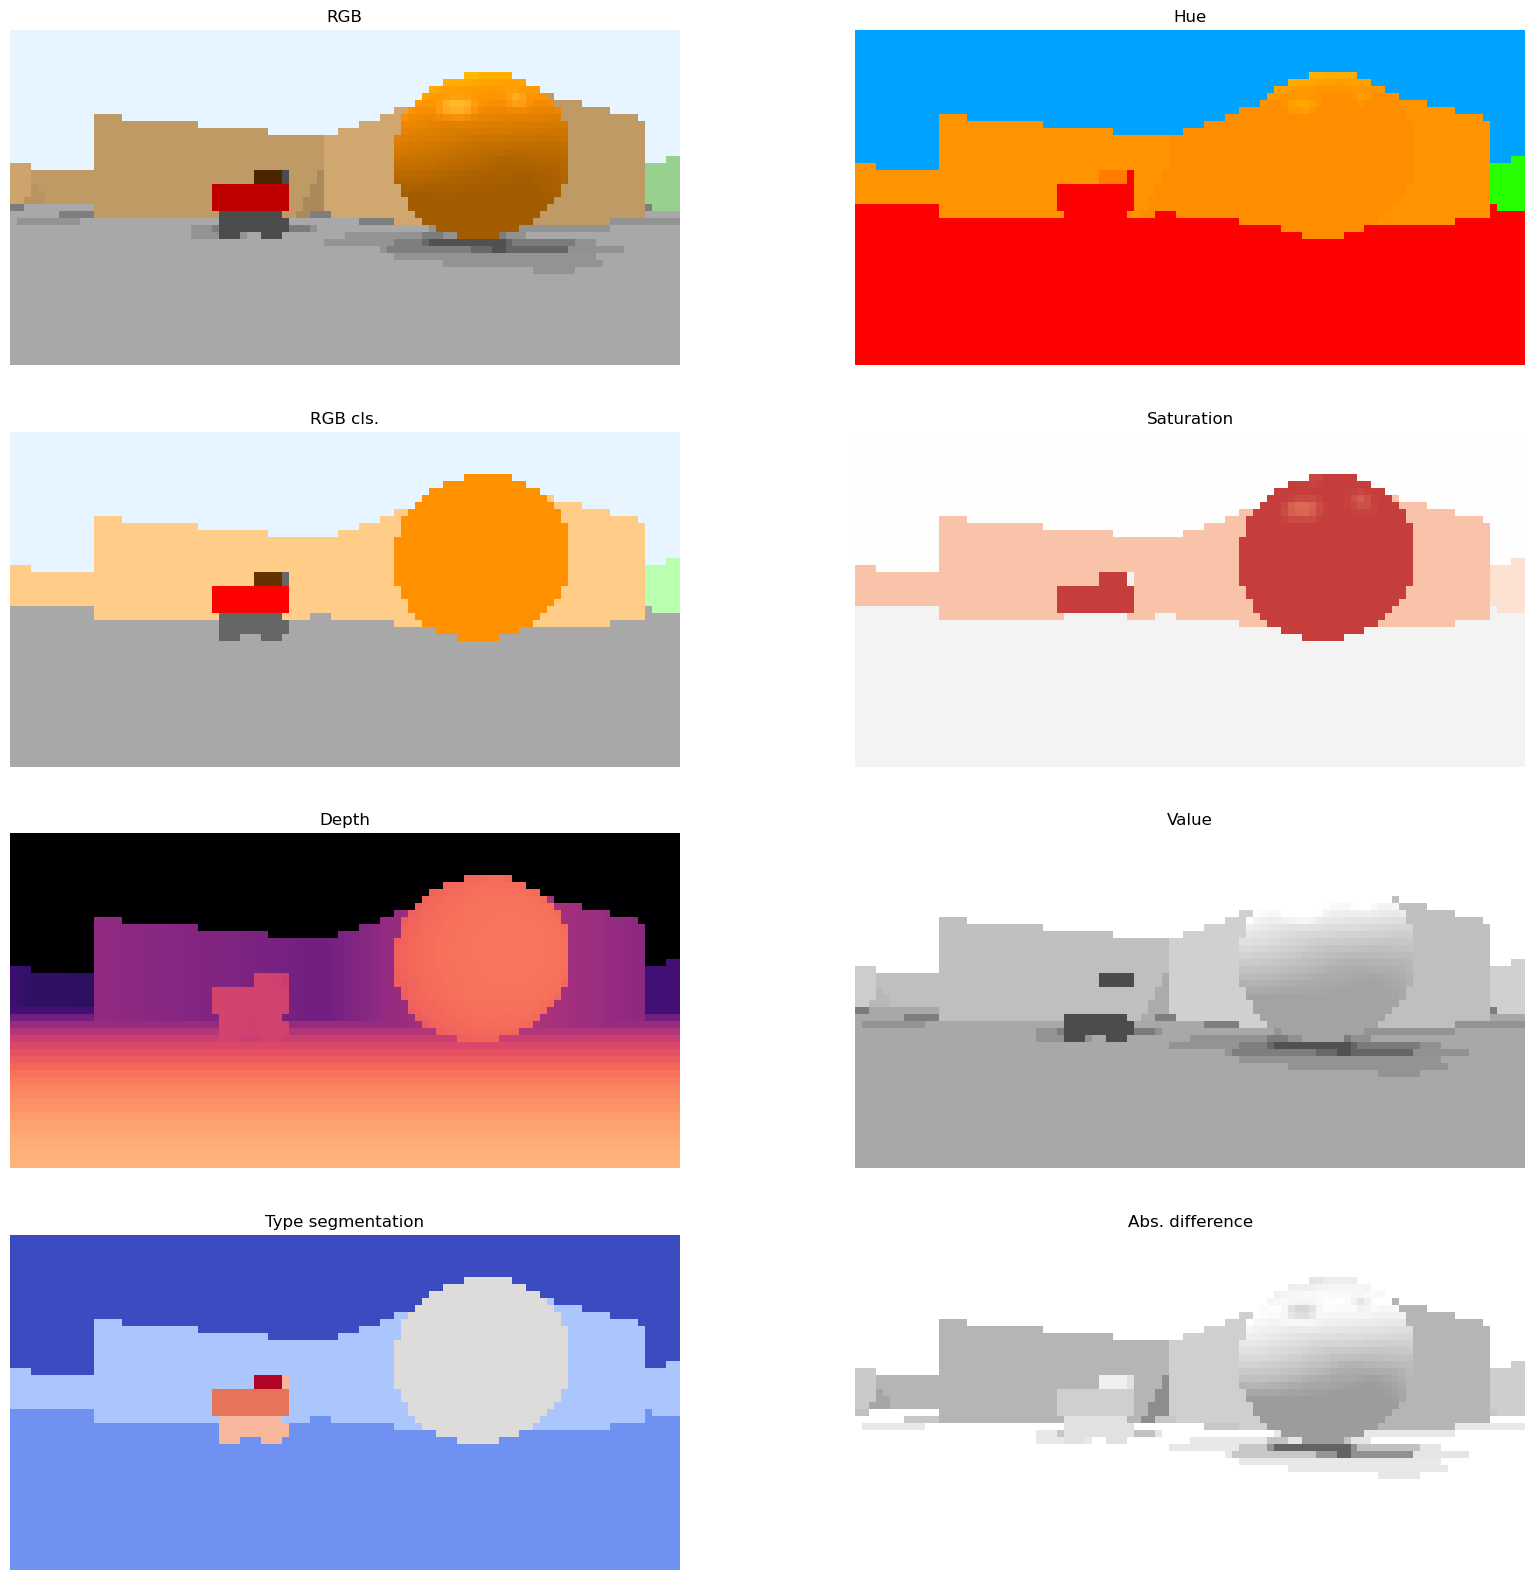

In [9]:
plot_image_components(images[0, 16])

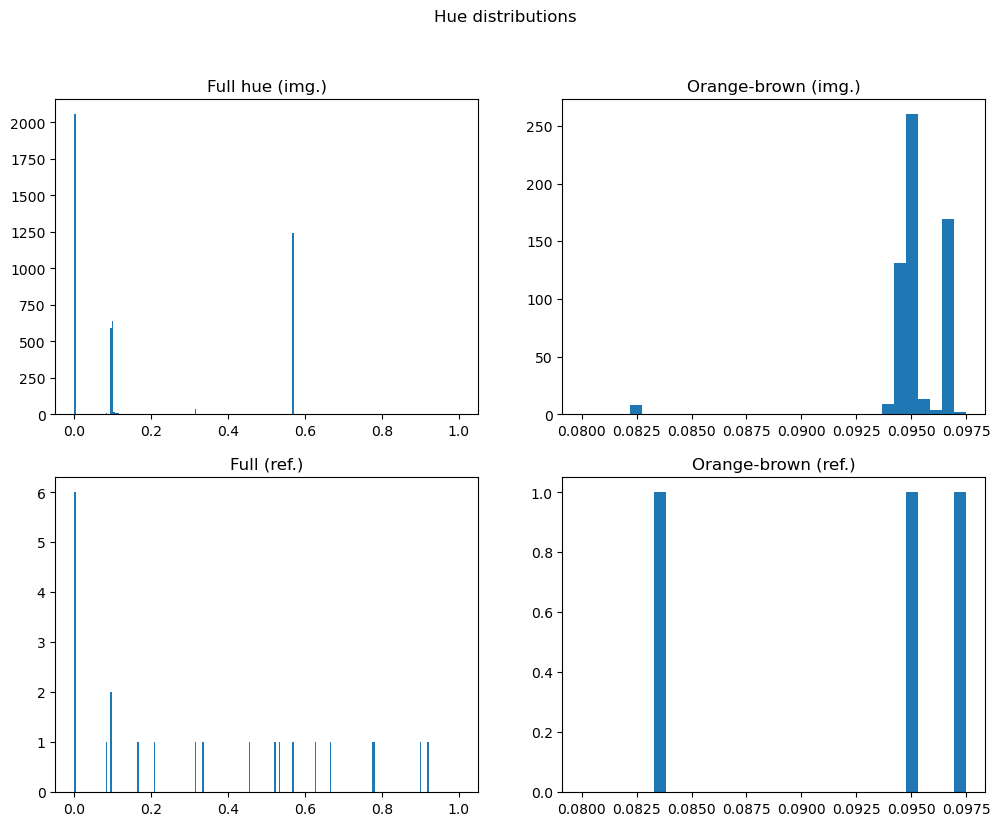

In [10]:
plot_hue_distributions((0, 16), (0.08, 0.0975))

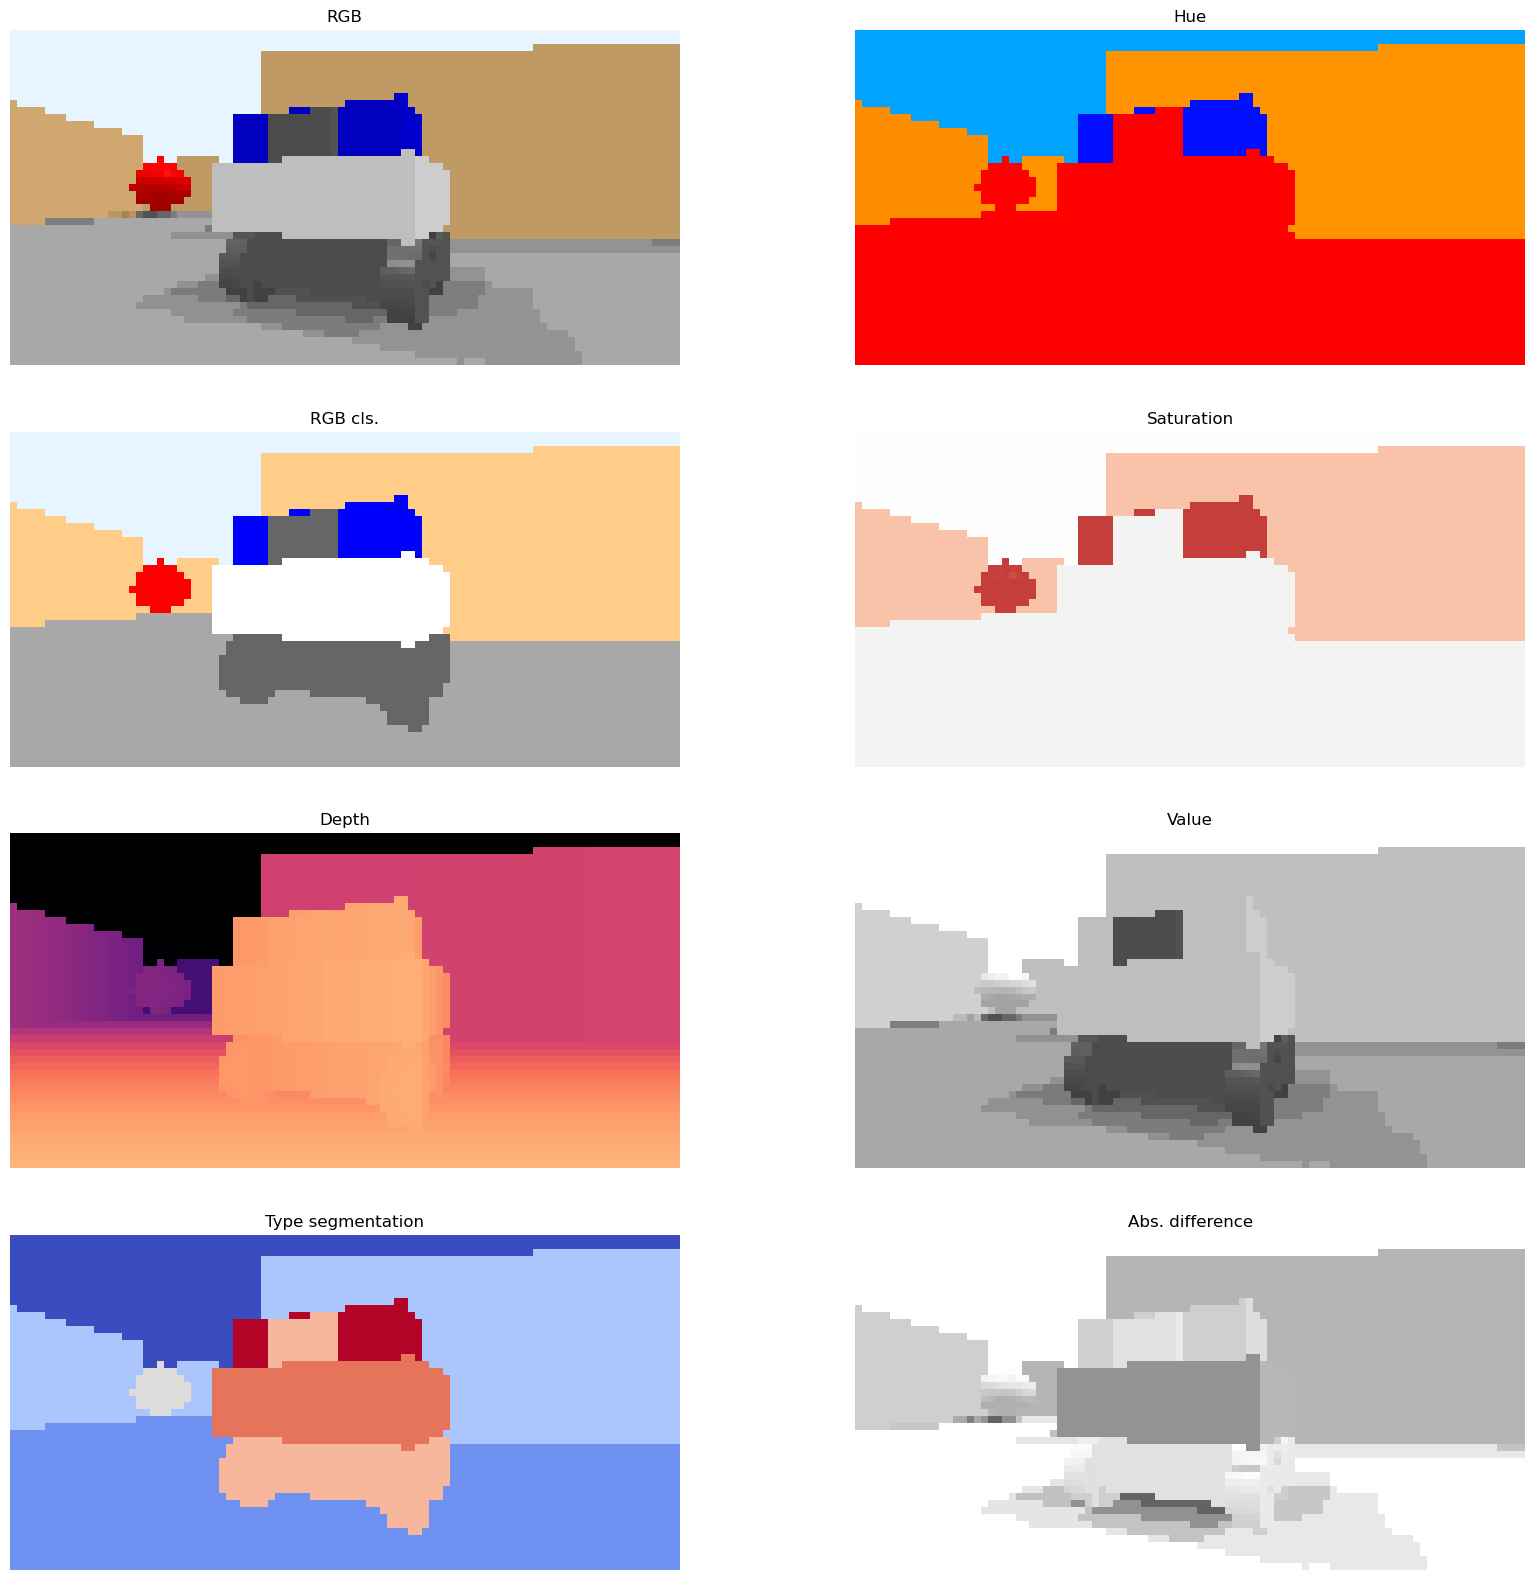

In [11]:
plot_image_components(images[0, 26])

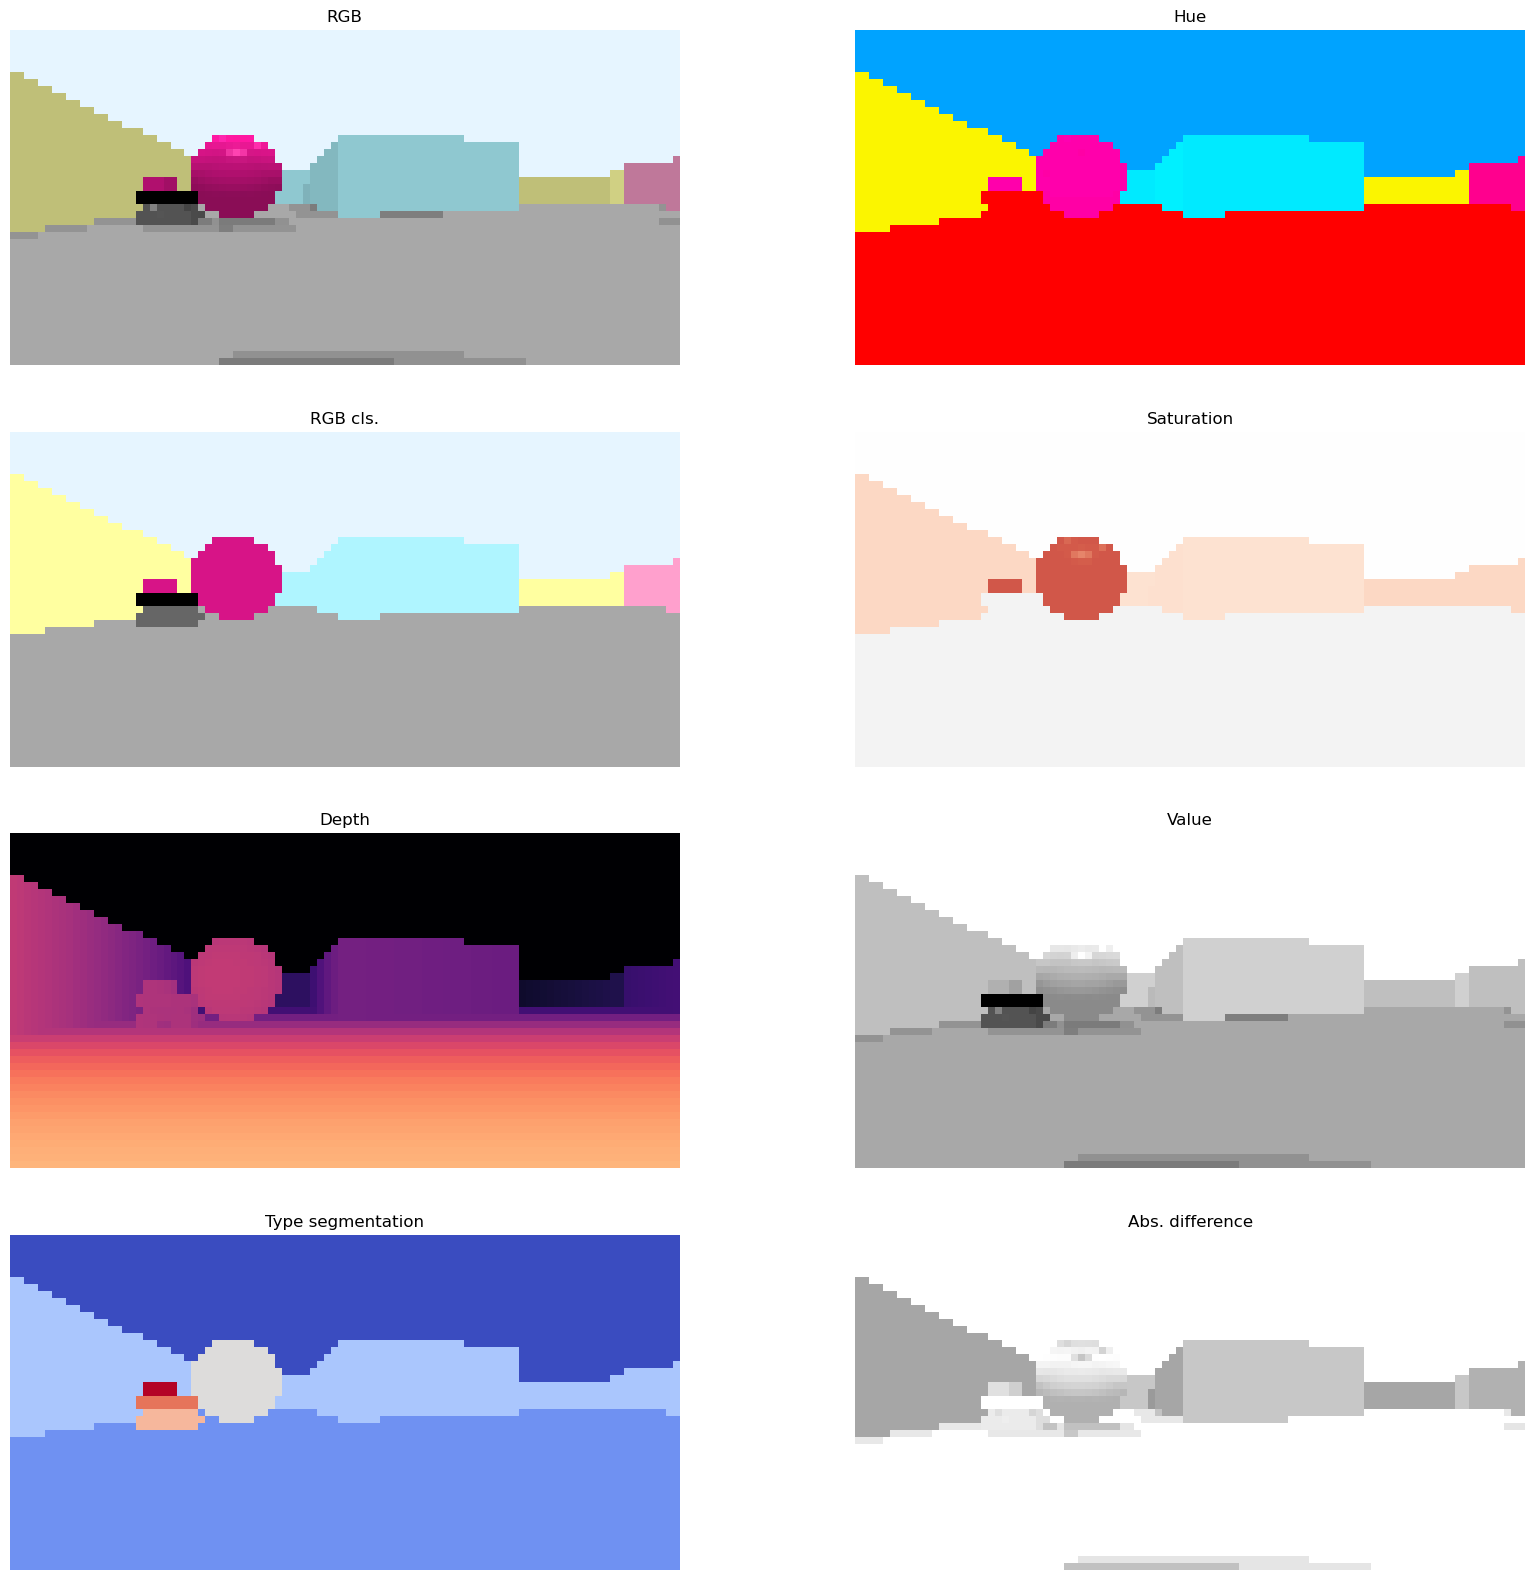

In [12]:
plot_image_components(images[0, 60])

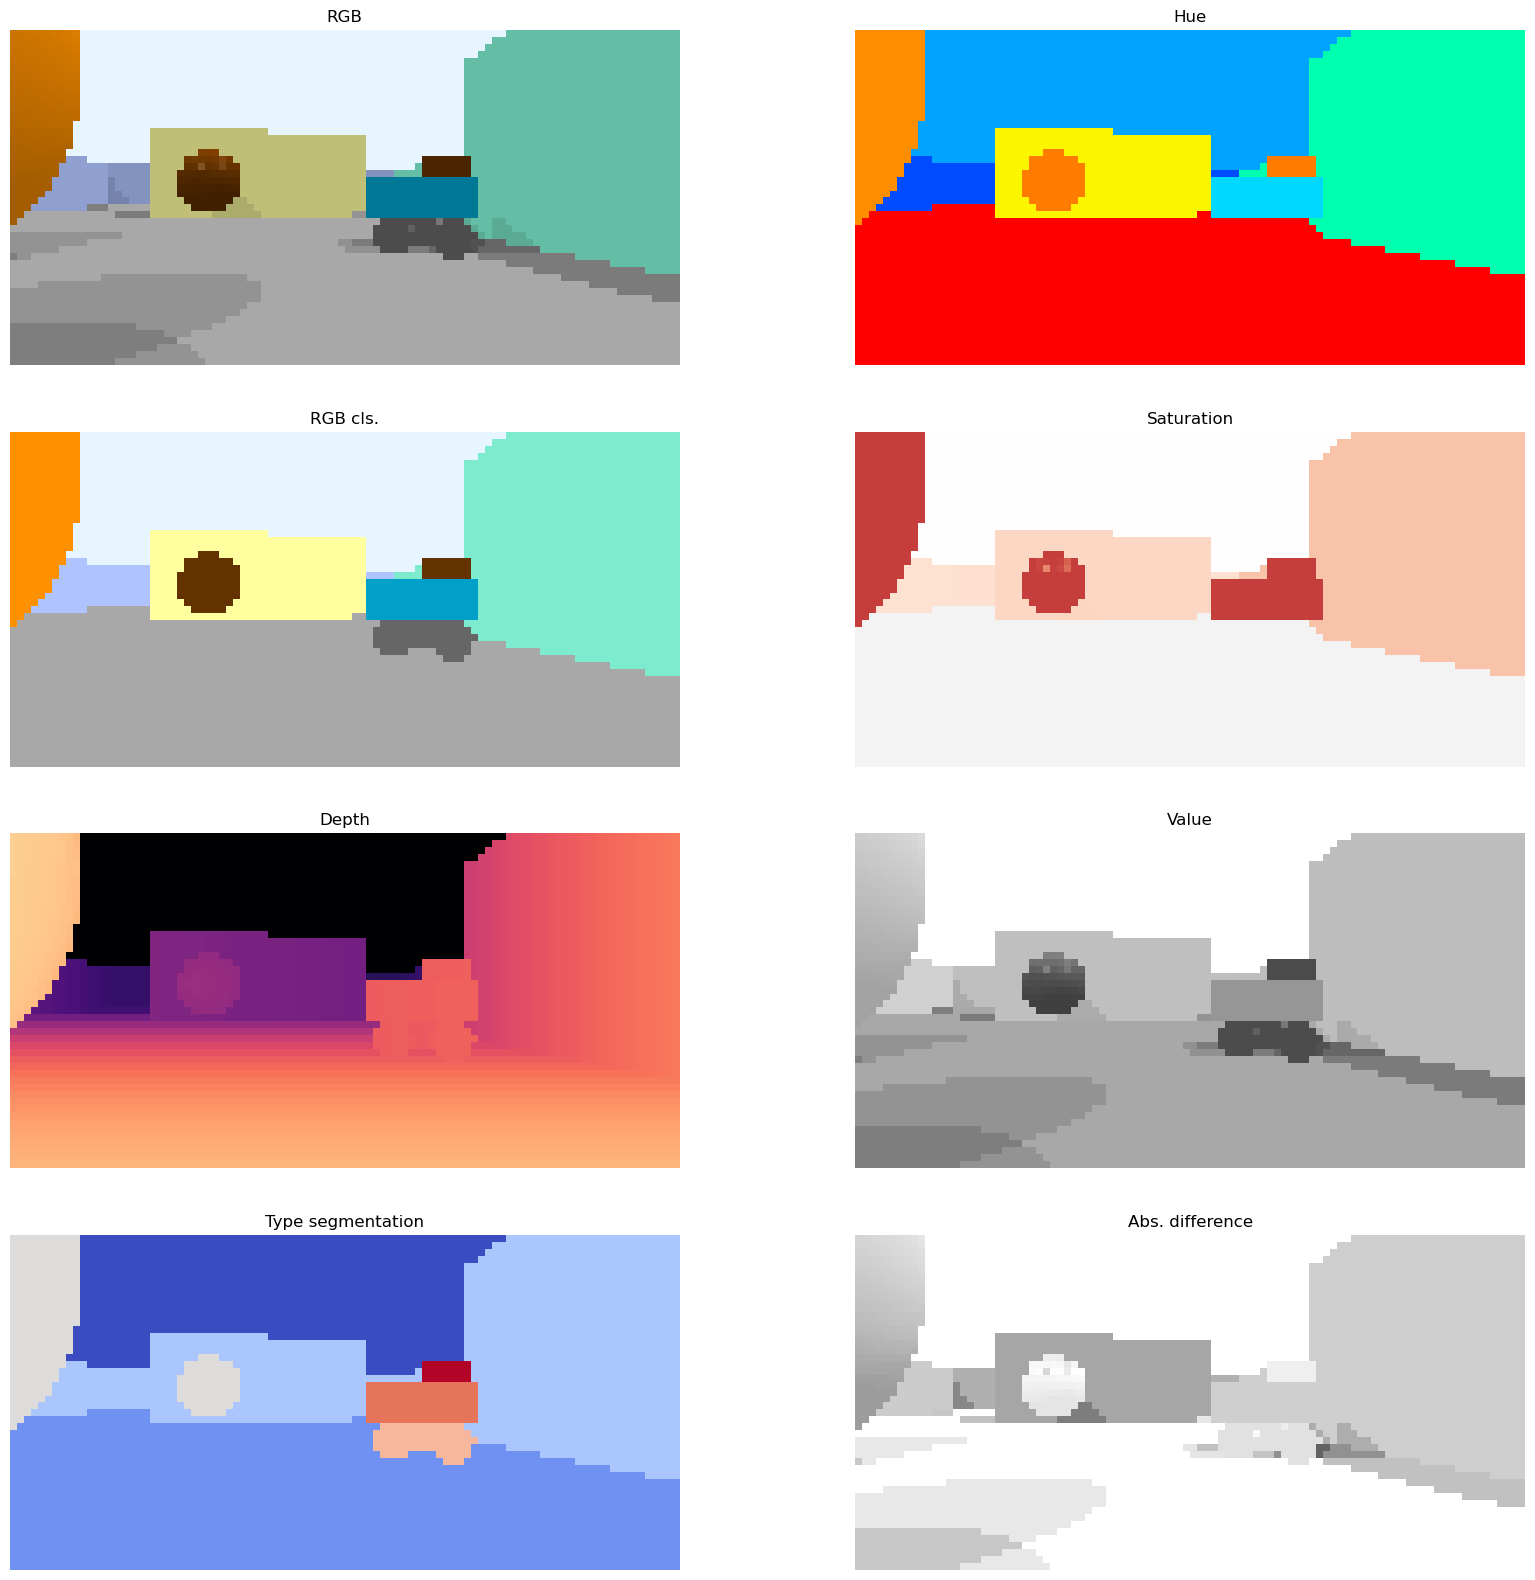

In [13]:
plot_image_components(images[0, 118])

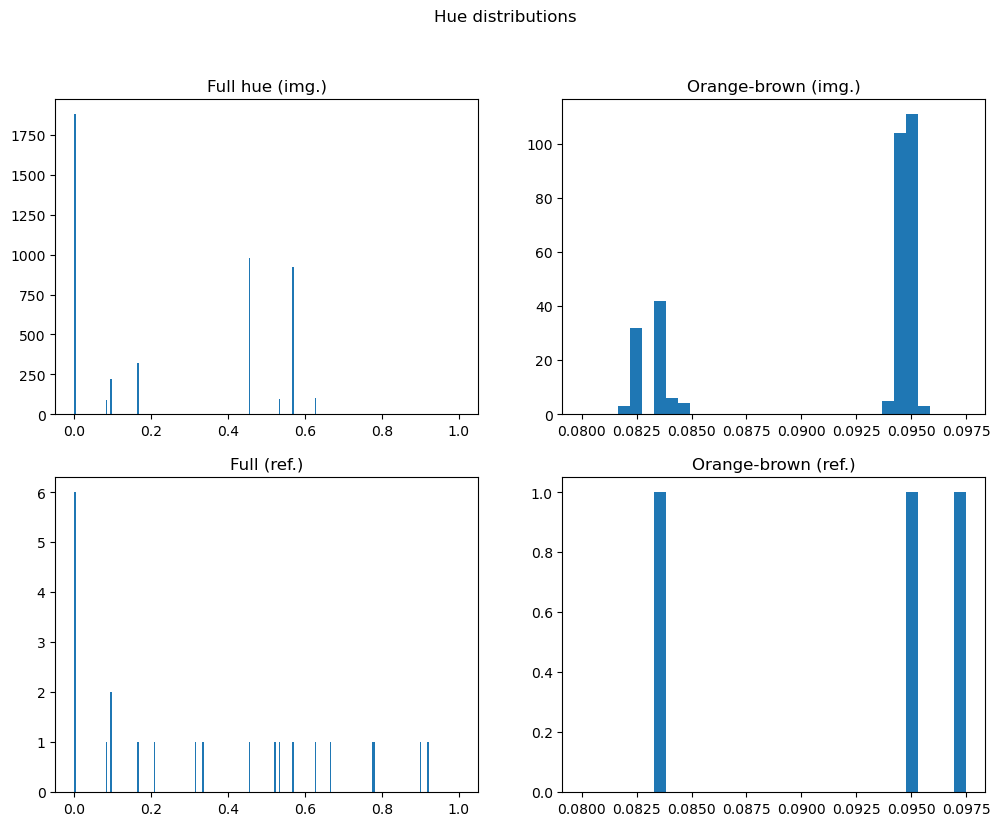

In [14]:
plot_hue_distributions((0, 118), (0.08, 0.0975))

## Process whole dataset

In [15]:
def convert_dataset(load_name: str, save_name: str):
    dataset = np.load(f'../data/{load_name}.npz')
    images = dataset['img']
    images = images.reshape((np.prod(images.shape[:2]), *images.shape[2:]))

    clr = images[:, :3]
    dep = images[:, 3]
    type_seg = images[:, 4]
    clr_seg = np.empty_like(type_seg)
    
    for i in range(len(images)):
        clr[i], clr_seg[i] = get_hsv_and_idx(images[i])

    np.savez_compressed(f'../data/{save_name}.npz', hsv=clr, dep=dep, type_seg=type_seg, clr_seg=clr_seg)

In [16]:
for k in range(7):
    print(k, end='... ')
    convert_dataset(f'rec_{k:02d}', f'rec_{k:02d}_img')

print('Done')

0... 1... 2... 3... 4... 5... 6... Done
